In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
wandb.login()
api = wandb.Api()

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: diana-onutu (oellm-team). Use `wandb login --relogin` to force relogin


# All runs in wandb

In [3]:
# Show all runs and their id in wandb of entity: oellm-team in project: gidd-gidd
runs = api.runs("oellm-team/gidd-gidd")
for run in runs:
    print(run.name, run.id)

small-mdlm-fineweb-4gpu-1node-snls hhicijrc
small-mdlm-fineweb-1gpu-1node-snls 0wmmboco
small-gidd-fineweb-pu=0.0-8gpu-2node-snls gx4jv5yf
small-gidd-fineweb-pu=0.0-4gpu-1node-snls 9q5m45zj
small-gidd-fineweb-pu=0.0-16gpu-4node-snls ozgc2g8a
small-gidd-fineweb-pu=0.0-1gpu-1node-snls 90vz1t06
small-gidd-fineweb-pu=0.0-2gpu-1node-snls i9xfn5u7
small-gidd-fineweb-pu=0.0-16gpu-4node-snls toryh3h2
small-gidd-fineweb-pu=0.0-8gpu-2node-snls ae1lk7qd
small-gidd-fineweb-pu=0.0-1gpu-1node-lrdn 20ljce1n
small-gidd-fineweb-pu=0.0-16gpu-4node-lrdn gah5du24
small-gidd-fineweb-pu=0.0-32gpu-8node-snls-h100 5t600f5m
small-gidd-fineweb-pu=0.0-4gpu-1node-snls ay5m0yiz
tiny-gidd-fineweb-pu=0.0-1gpu-1node-snls-h100 u8i15qxg
small-gidd-fineweb-pu=0.0-4gpu-1node-lrdn gc38r3ha
tiny-gidd-fineweb-pu=0.0-1gpu-1node-snls-h100 q8d30g7a
small-gidd-fineweb-pu=0.0-xgpu-xnode-snls-xbs vuzu6lsc
small-gidd-fineweb-pu=0.0-xgpu-xnode-snls-xbs gokfu9dp
small-gidd-fineweb-pu=0.0-16gpu-4node-snls-64bs sh29jiah
small-gidd-fin

In [4]:
# Show all runs and their id in wandb of entity: oellm-team in project: gidd-gidd that have in the name 1B and 64 gpu
runs = api.runs("oellm-team/gidd-gidd")
for run in runs:
    if "1B" in run.name and "64gpu" in run.name:
        print(run.name, run.id)

1B-gidd-fineweb-pu=0.0-64gpu-16node-lrdn-a100-8mbs d6tk0gp8
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs tt63u77w
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-h100-8mbs jmhnpnao
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs ix31y022
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs 1xn8evn4
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs 1kcwbgcv
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs ufx3llwn
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-h100-8mbs q6ukez1v
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-h100-8mbs o4kgpttz
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-h100-8mbs e5w5vol6
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-h100-8mbs 30fg328j
1B-gidd-fineweb-pu0.0-64gpu-16node-jsc-a100-8bs 8kg1z7gm


# Specific run wandb

In [39]:
# Select a specific run
entity = "oellm-team"
project = "gidd-gidd"
run_id = "b3flyymv"

run = api.run(f"{entity}/{project}/{run_id}")

In [40]:
history = run.history(keys=["train/tokens_per_sec"])
history

,_step,train/tokens_per_sec
0,9,164128.174471
1,19,176927.094618
2,29,174139.667962
3,39,167127.680886
4,49,172235.687477
...,...,...
195,1959,182785.968862
196,1969,160160.026566
197,1979,165547.330340
198,1989,148336.835512


In [8]:
# Select only data from the 1000 step and take the mean of all values from step 1000 until the final one (in our case 2000)
history[history['_step'] > 1000]["train/tokens_per_sec"].mean()

172152.19696780865

# Extract throughput over all runs with 1B model

In [9]:
entity = "oellm-team"
projects = ["gidd", "ar"]
systems = ["snls-a100", "snls-h100", "lrdn", "jsc"]
gpu_counts = [1, 4, 8, 16, 32, 64, 128]

throughput = {prj: {hpc: {gpu: [] for gpu in gpu_counts} for hpc in systems} for prj in projects}

for prj in projects:
    project_name = f"gidd-{prj}"
    runs = api.runs(f"{entity}/{project_name}")

    for run in runs:
        if "1B" not in run.name:
            continue

        for proj_key in projects:
            if proj_key not in run.name:
                continue

            for hpc in systems:
                if hpc not in run.name:
                    continue

                for gpu in gpu_counts:
                    
                    if f"-{gpu}gpu" in run.name:
                        print(run.name, run.id)
                        history = run.history(keys=["train/tokens_per_sec"])
                        temp_throughput = history[history['_step'] > 1000]["train/tokens_per_sec"].mean()
                        throughput[proj_key][hpc][gpu].append(temp_throughput)
                        break  # stop checking further GPU counts once matched

1B-gidd-fineweb-pu=0.0-1gpu-1node-lrdn-a100-8mbs u8fwjeqm
1B-gidd-fineweb-pu=0.0-4gpu-1node-lrdn-a100-8mbs a42kkpbd
1B-gidd-fineweb-pu=0.0-8gpu-2node-lrdn-a100-8mbs pffkiy98
1B-gidd-fineweb-pu=0.0-1gpu-1node-snls-a100-8mbs 4nu60665
1B-gidd-fineweb-pu=0.0-16gpu-4node-lrdn-a100-8mbs ahf1bog5
1B-gidd-fineweb-pu=0.0-32gpu-8node-lrdn-a100-8mbs d34pmkr5
1B-gidd-fineweb-pu=0.0-64gpu-16node-lrdn-a100-8mbs d6tk0gp8
1B-gidd-fineweb-pu=0.0-4gpu-1node-snls-a100-8mbs 6xgu84xv
1B-gidd-fineweb-pu=0.0-8gpu-2node-snls-a100-8mbs zxnmxro7
1B-gidd-fineweb-pu=0.0-16gpu-4node-snls-a100-8mbs ahsjsmw4
1B-gidd-fineweb-pu=0.0-32gpu-8node-snls-a100-8mbs v0ruuu6t
1B-gidd-fineweb-pu=0.0-64gpu-16node-snls-a100-8mbs tt63u77w
1B-gidd-fineweb-pu=0.0-1gpu-1node-snls-h100-8mbs 488un4kk
1B-gidd-fineweb-pu=0.0-4gpu-1node-snls-h100-8mbs t197sbqz
1B-gidd-fineweb-pu=0.0-8gpu-2node-snls-h100-8mbs ucrxlgfy
1B-gidd-fineweb-pu=0.0-16gpu-4node-snls-h100-8mbs c55y4mg2
1B-gidd-fineweb-pu=0.0-128gpu-32node-lrdn-a100-8mbs 34c9kn90
1B

In [10]:
throughput

{'gidd': {'snls-a100': {1: [10896.021071920271,
    10965.468663510594,
    10973.859304422369,
    10967.661117348947,
    10833.366007728635],
   4: [41431.69022472788,
    41602.38216284637,
    41212.906299186645,
    41011.34347171548,
    40435.33770201286,
    41467.22578802804],
   8: [59081.13271541198,
    59273.29823515645,
    58860.40202114258,
    59327.18402090466,
    59178.9576023538],
   16: [89721.67178037365,
    89487.71819740153,
    89612.79280201657,
    89658.82428752446,
    89300.84382545072],
   32: [172287.2428465683,
    172346.18987983066,
    172133.8649982669,
    172152.19696780865,
    172010.651720154],
   64: [325938.0066077711,
    326233.9113486024,
    326023.95621294033,
    326146.2262238289,
    326091.4251553537],
   128: []},
  'snls-h100': {1: [22088.633400277922,
    18667.60605143874,
    21992.299059966845,
    21847.982186957925,
    20697.58115065037],
   4: [81310.44228863948,
    71822.75645771292,
    78128.3947648908,
    76807.890

# Extract the reference throguhput (on 1 GPU)

In [16]:
# Where there are multiple runs, just take the mean.
T1 = {prj: {hpc: 0 for hpc in systems} for prj in projects}
for model in throughput:
    for hpc in throughput[model]:
        print(f"model: {model}, system {hpc}")
        print(throughput[model][hpc][1])
        print("\n")
        T1[model][hpc] = np.mean(throughput[model][hpc][1])

model: gidd, system snls-a100
[10896.021071920271, 10965.468663510594, 10973.859304422369, 10967.661117348947, 10833.366007728635]


model: gidd, system snls-h100
[22088.633400277922, 18667.60605143874, 21992.299059966845, 21847.982186957925, 20697.58115065037]


model: gidd, system lrdn
[10870.391740883559]


model: gidd, system jsc
[10802.963533768569]


model: ar, system snls-a100
[8790.350730121336]


model: ar, system snls-h100
[18441.1254878355]


model: ar, system lrdn
[9044.734553948354]


model: ar, system jsc
[8695.349005648379]




In [17]:
T1

{'gidd': {'snls-a100': 10927.275232986163,
  'snls-h100': 21058.82036985836,
  'lrdn': 10870.391740883559,
  'jsc': 10802.963533768569},
 'ar': {'snls-a100': 8790.350730121336,
  'snls-h100': 18441.1254878355,
  'lrdn': 9044.734553948354,
  'jsc': 8695.349005648379}}

# Calculate scling efficiency as: T(n) / (T(1) * n)

In [19]:
entity = "oellm-team"
projects = ["gidd", "ar"]
systems = ["snls-a100", "snls-h100", "lrdn", "jsc"]
gpu_counts = [4, 8, 16, 32, 64, 128]

eff = {prj: {hpc: {gpu: [] for gpu in gpu_counts} for hpc in systems} for prj in projects}

for model in throughput:
    for hpc in throughput[model]:
        for gpu_count in throughput[model][hpc]:
            if gpu_count != 1:
                print(f"model: {model}, hpc: {hpc}, gpu count: {gpu_count}")

                print(f"throughput: {throughput[model][hpc][gpu_count]}")

                print(f"T1: {T1[model][hpc]}")
                
                temp_eff = throughput[model][hpc][gpu_count] / (T1[model][hpc] * gpu_count)
                print(f"eff: {temp_eff}")

                eff[model][hpc][gpu_count].extend(temp_eff.tolist())
                
                print("\n")

model: gidd, hpc: snls-a100, gpu count: 4
throughput: [41431.69022472788, 41602.38216284637, 41212.906299186645, 41011.34347171548, 40435.33770201286, 41467.22578802804]
T1: 10927.275232986163
eff: [0.94789619 0.95180137 0.94289073 0.93827927 0.92510111 0.94870919]


model: gidd, hpc: snls-a100, gpu count: 8
throughput: [59081.13271541198, 59273.29823515645, 58860.40202114258, 59327.18402090466, 59178.9576023538]
T1: 10927.275232986163
eff: [0.67584475 0.67804298 0.67331975 0.6786594  0.67696379]


model: gidd, hpc: snls-a100, gpu count: 16
throughput: [89721.67178037365, 89487.71819740153, 89612.79280201657, 89658.82428752446, 89300.84382545072]
T1: 10927.275232986163
eff: [0.513175   0.51183687 0.51255225 0.51281554 0.51076802]


model: gidd, hpc: snls-a100, gpu count: 32
throughput: [172287.2428465683, 172346.18987983066, 172133.8649982669, 172152.19696780865, 172010.651720154]
T1: 10927.275232986163
eff: [0.49270987 0.49287845 0.49227124 0.49232366 0.49191887]


model: gidd, hpc: s

# Plot scaling efficiency

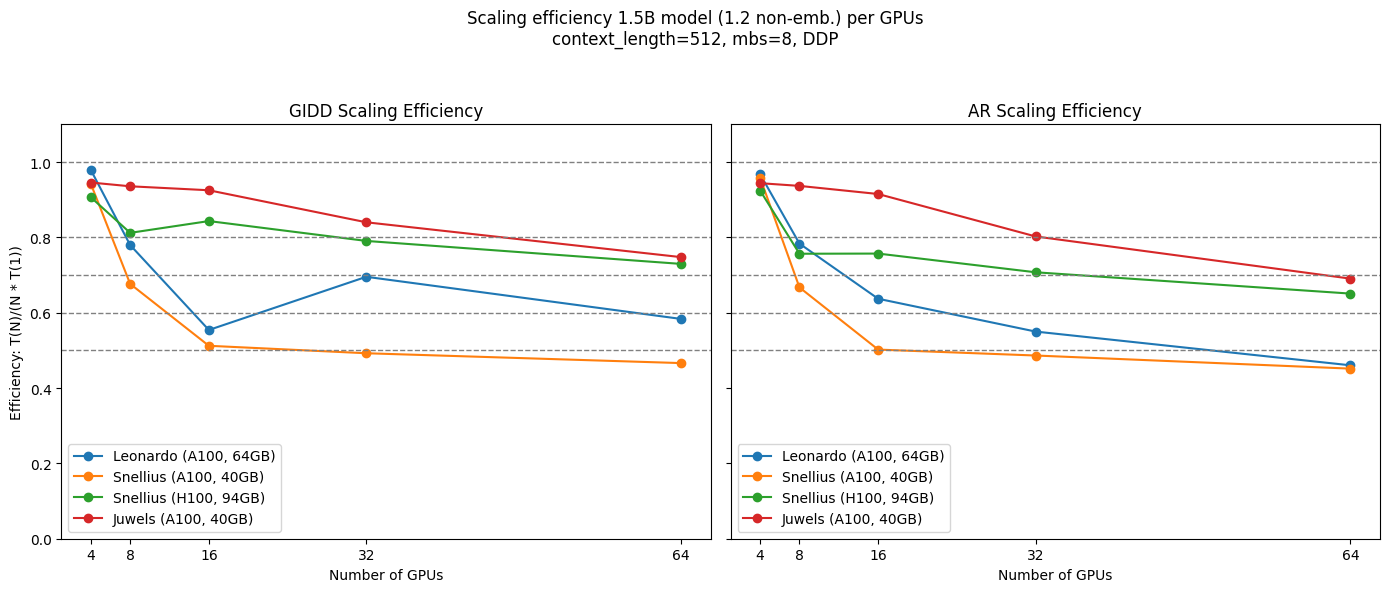

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
gpus = [4, 8, 16, 32, 64] # could also incl 128 but don't have many runs

mean_gidd_snls_a100 = np.array([np.mean(lst) for lst in list(eff["gidd"]["snls-a100"].values())[:-1]])
mean_gidd_snls_h100 = np.array([np.mean(lst) for lst in list(eff["gidd"]["snls-h100"].values())[:-1]])

mean_ar_snls_a100 = np.array([np.mean(lst) for lst in list(eff["ar"]["snls-a100"].values())[:-1]])
mean_ar_snls_h100 = np.array([np.mean(lst) for lst in list(eff["ar"]["snls-h100"].values())[:-1]])


# --- GIDD ---
axes[0].plot(gpus, list(eff["gidd"]["lrdn"].values())[:-1], marker='o', linestyle='-', label='Leonardo (A100, 64GB)')
axes[0].plot(gpus, mean_gidd_snls_a100, marker='o', linestyle='-', label='Snellius (A100, 40GB)')
axes[0].plot(gpus, mean_gidd_snls_h100, marker='o', linestyle='-', label='Snellius (H100, 94GB)')
axes[0].plot(gpus, list(eff["gidd"]["jsc"].values())[:-1], marker='o', linestyle='-', label='Juwels (A100, 40GB)')



axes[0].axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
axes[0].axhline(y=0.8, color='gray', linestyle='--', linewidth=1)
axes[0].axhline(y=0.7, color='gray', linestyle='--', linewidth=1)
axes[0]axhline(y=0.6, color='gray', linestyle='--', linewidth=1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('GIDD Scaling Efficiency')
axes[0].set_xlabel('Number of GPUs')
axes[0].set_ylabel('Efficiency: T(N)/(N * T(1))')
axes[0].set_xticks(gpus)
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# --- AR ---
axes[1].plot(gpus, list(eff["ar"]["lrdn"].values())[:-1], marker='o', linestyle='-', label='Leonardo (A100, 64GB)')
axes[1].plot(gpus, mean_ar_snls_a100, marker='o', linestyle='-', label='Snellius (A100, 40GB)')
axes[1].plot(gpus, mean_ar_snls_h100, marker='o', linestyle='-', label='Snellius (H100, 94GB)')
axes[1].plot(gpus, list(eff["ar"]["jsc"].values())[:-1], marker='o', linestyle='-', label='Juwels (A100, 40GB)')



axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=0.8, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=0.7, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=0.6, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('AR Scaling Efficiency')
axes[1].set_xlabel('Number of GPUs')
axes[1].set_xticks(gpus)
axes[1].legend()

plt.suptitle('Scaling efficiency 1.5B model (1.2 non-emb.) per GPUs\ncontext_length=512, mbs=8, DDP')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Plot confidence intervals for the experiments we repeated

gidd snls-a100: 
[0.93355006 0.67468038 0.51137729 0.49208079 0.46612923]
[0.94244631 0.67656613 0.51222954 0.49242042 0.46627404]
[0.95134256 0.67845189 0.51308179 0.49276005 0.46641885]
gidd snls-h100: 
[0.86723609 0.7881011  0.81197409 0.77917335 0.70539798]
[0.90663221 0.81205361 0.84335336 0.79062632 0.7295876 ]
[0.94602834 0.83600612 0.87473262 0.8020793  0.75377722]


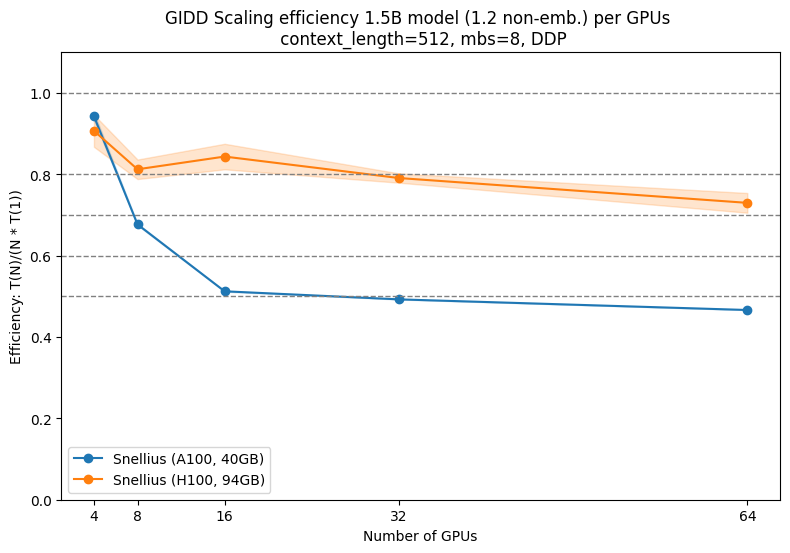

In [38]:
gpus = [4, 8, 16, 32, 64] # could also incl 128 but don't have many runs

mean_gidd_snls_a100 = np.array([np.mean(lst) for lst in list(eff["gidd"]["snls-a100"].values())[:-1]])
mean_gidd_snls_h100 = np.array([np.mean(lst) for lst in list(eff["gidd"]["snls-h100"].values())[:-1]])
std_gidd_snls_a100 = np.array([np.std(lst) for lst in list(eff["gidd"]["snls-a100"].values())[:-1]])
std_gidd_snls_h100 = np.array([np.std(lst) for lst in list(eff["gidd"]["snls-h100"].values())[:-1]])

mean_ar_snls_a100 = np.array([np.mean(lst) for lst in list(eff["ar"]["snls-a100"].values())[:-1]])
mean_ar_snls_h100 = np.array([np.mean(lst) for lst in list(eff["ar"]["snls-h100"].values())[:-1]])
std_ar_snls_a100 = np.array([np.std(lst) for lst in list(eff["ar"]["snls-a100"].values())[:-1]])
std_ar_snls_h100 = np.array([np.std(lst) for lst in list(eff["ar"]["snls-h100"].values())[:-1]])

print("gidd snls-a100: ")
print(mean_gidd_snls_a100 - std_gidd_snls_a100)
print(mean_gidd_snls_a100)
print(mean_gidd_snls_a100 + std_gidd_snls_a100)

print("gidd snls-h100: ")
print(mean_gidd_snls_h100 - std_gidd_snls_h100)
print(mean_gidd_snls_h100)
print(mean_gidd_snls_h100 + std_gidd_snls_h100)

plt.figure(figsize=(8, 6))
plt.plot(gpus, mean_gidd_snls_a100, marker='o', linestyle='-', label='Snellius (A100, 40GB)')
plt.fill_between(gpus, mean_gidd_snls_a100-std_gidd_snls_a100, mean_gidd_snls_a100+std_gidd_snls_a100,
                     color='C0', alpha=0.2)

plt.plot(gpus, mean_gidd_snls_h100, marker='o', linestyle='-', label='Snellius (H100, 94GB)')
plt.fill_between(gpus, mean_gidd_snls_h100-std_gidd_snls_h100, mean_gidd_snls_h100+std_gidd_snls_h100,
                     color='C1', alpha=0.2)

plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.8, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.7, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.6, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Number of GPUs')
plt.ylabel('Efficiency: T(N)/(N * T(1))')
plt.xticks(gpus)
plt.ylim(0, 1.1)
plt.legend()

plt.title('GIDD Scaling efficiency 1.5B model (1.2 non-emb.) per GPUs \n context_length=512, mbs=8, DDP')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()